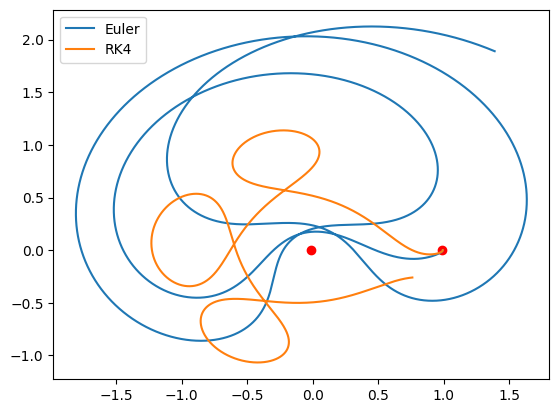

In [ ]:
import sympy as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.optimize import fsolve

T0 = 17.0652165601579625588917206249
miu = 0.012277471

#Schemat Eulera
def Euler(f, a, b, x0, N):
  h = (b-a)/N
  T = [a]
  X = [x0]
  t = a
  x = x0
  for i in range(N):
    x = x + h*f(t, x)
    t = t + h
    T.append(t)
    X.append(x)
  return T, X

#Schemat Rungego_Kutty 4
def RK4(f, a, b, x0, N):
  h = (b-a)/N
  T = [a]
  X = [x0]
  t = a
  x = x0
  for i in range(N):
    K1 = h*f(t, x)
    K2 = h*f(t + h/2, x + K1/2)
    K3 = h*f(t + h/2, x + K2/2)
    K4 = h*f(t + h, x + K3)
    x = x + (K1 + 2*K2 + 2*K3 + K4)/6
    t = t + h
    T.append(t)
    X.append(x)
  return T, X

#Obliczenie wartości funkcji stosując schemat Eulera z zadanymi warunkami początkowymi
def solveBVP1(f, a, b, alpha, beta, N):
  T, X = Euler(f, 0, T0, np.array([a, alpha, b, beta]), N) #4-wymiarowy schemat Eulera z wektorem początkowym [a, alpha, b, beta]
  X = np.array(X)
  return T, X[:, 0], X[:, 2] #przekazywanie wartości funkcji x i y, zapisanych odpowiednio na pierwszej i treciej współrzędnej wektorów

#Obliczenie wartości funkcji stosując schemat Rungego-Kutty 4 z zadanymi warunkami początkowymi
def solveBVP2(f, a, b, alpha, beta, N):
  T, X = RK4(f, 0, T0, np.array([a, alpha, b, beta]), N) #4-wymiarowy schemat Rungego-Kutty 4
  X = np.array(X)
  return T, X[:, 0], X[:, 2] #przekazywanie wartości funkcji x i y, zapisanych odpowiednio na pierwszej i treciej współrzędnej wektorów

#Przekształcenie układu dwóch równań do układu z jednym równaniem i 4-wymiarowym rozwiązaniem, gdzie pierwsza i czwarta współrzędna to x i y, a druga
#i czwarta - pochodne odpowiednich funkcji
def fVectorial(t, x):
  return np.array([x[1], f1(t, x[0], x[2], x[3]), x[3], f2(t, x[0], x[2], x[1])]) #x'=u, u'=f1(x, y, v), y'=v, v'=f2(x, y, u)

#Funkcja opisująca pierwsze równanie układu, która przyjmuje wartości x, y i y'
def f1(t, x, y, v):
  return x + 2*v - (1-miu)*(x+miu)/((x+miu)**2 + y**2)**(3/2) - miu*(x-1+miu)/((x-1+miu)**2 + y**2)**(3/2)

#Funkcja opisująca drugie równanie układu, która przyjmuje wartości x, y i x'
def f2(t, x, y, u):
  return y - 2*u - (1-miu)*y/((x+miu)**2 + y**2)**(3/2) - miu*y/((x-1+miu)**2 + y**2)**(3/2)

T1, X1, Y1 = solveBVP1(fVectorial, 0.994, 0, 0, -2.00158510637908252240537862224, 24000) #Euler
T2, X2, Y2 = solveBVP2(fVectorial, 0.994, 0, 0, -2.00158510637908252240537862224, 6000) #RK4

plt.plot(X1, Y1, label="Euler")
plt.plot(X2, Y2, label="RK4")
plt.scatter([-miu, 1-miu], [0, 0], color="red") #Zaznaczenie położeń Ziemi i Księżyca
plt.legend(loc="best")
plt.show()

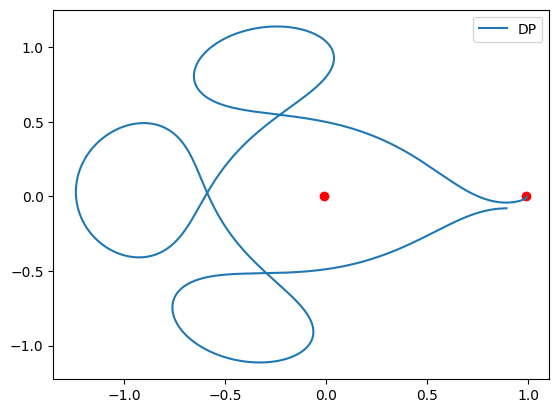

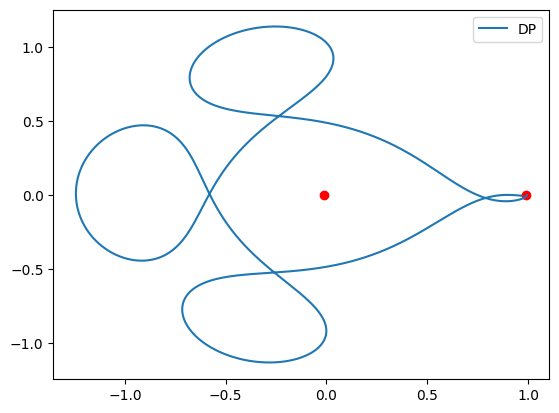

In [12]:
#Schemat Dormanda-Prince'a
def DP(f, a, b, x0, N):
  h = (b-a)/N
  T = [a]
  X = [x0]
  t = a
  x = x0
  for i in range(N):
    D1 = h*f(t, x)
    D2 = h*f(t + h/5, x + D1/5)
    D3 = h*f(t + 3*h/10, x + 3*D1/40 + 9*D2/40)
    D4 = h*f(t + 4*h/5, x + 44*D1/45 - 56*D2/15 + 32*D3/9)
    D5 = h*f(t + 8*h/9, x + 19372*D1/6561 - 25360*D2/2187 + 64448*D3/6561 - 212*D4/729)
    D6 = h*f(t + h, x + 9017*D1/3168 - 355*D2/33 + 46732*D3/5247 + 49*D4/176 - 5103*D5/18656)
    x = x + 35*D1/384 + 500*D3/1113 + 125*D4/192 - 2187*D5/6784 + 11*D6/84
    t = t + h
    T.append(t)
    X.append(x)
  return T, X

#Obliczenie wartości funkcji stosując schemat Dormanda-Prince'a z zadanymi warunkami początkowymi
def solveBVP3(f, a, b, alpha, beta, N):
  T, X = DP(f, 0, T0, np.array([a, alpha, b, beta]), N) #4-wymiarowy schemat Dormanda-Prince'a
  X = np.array(X)
  return T, X[:, 0], X[:, 2] #przekazywanie wartości funkcji x i y, zapisanych odpowiednio na pierwszej i treciej współrzędnej wektorów

T3, X3, Y3 = solveBVP3(fVectorial, 0.994, 0, 0, -2.00158510637908252240537862224, 5000) #Dormand-Prince

plt.plot(X3, Y3, label="DP")
plt.scatter([-miu, 1-miu], [0, 0], color="red")
plt.legend(loc="best")
plt.show()

T4, X4, Y4 = solveBVP3(fVectorial, 0.994, 0, 0, -2.00158510637908252240537862224, 6000) #Dormand-Prince

plt.plot(X4, Y4, label="DP")
plt.scatter([-miu, 1-miu], [0, 0], color="red")
plt.legend(loc="best")
plt.show()

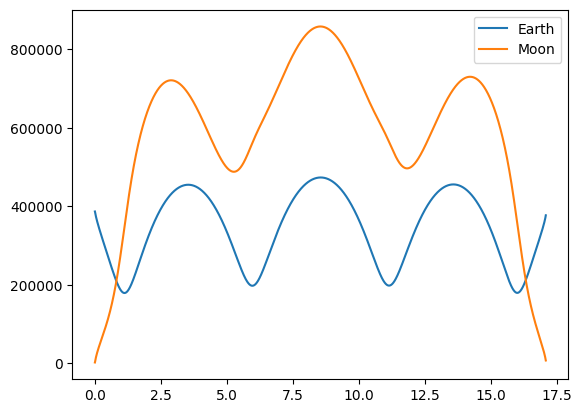

In [ ]:
#Odległość między położeniem satelity, obliczonym za pomocą metody Dormanda-Prine'a, a Ziemią i Księżycem w kolejnych chwilach czasu
def dist(T, X, Y):
  DE = np.zeros(len(T)) #Inicjalizacja tablicy odległości od Ziemi do satelity
  DM = np.zeros(len(T)) #Inicjalizacja tablicy odległości od Księżyca do satelity
  for i in range(len(T)):
    DE[i] = np.linalg.norm([X[i]+miu, Y[i]]) * 384400 #Obliczenie normy wektora [X[i], Y[i]] - [-miu, 0] z przeskalowaniem o odległość Ziemi od Księżyca w km
    DM[i] = np.linalg.norm([X[i]-1+miu, Y[i]]) * 384400 #Obliczenie normy wektora [X[i], Y[i]] - [1-miu, 0]
  return DE, DM

DE, DM = dist(T3, X3, Y3)
#Rysowanie wykresu prezentującego odległość satelity od Ziemi i Księżyca
plt.plot(T3, DE, label="Earth")
plt.plot(T3, DM, label="Moon")
plt.legend(loc="best")
plt.show()

In [14]:
#Obliczenie odległości punktu (x(0), y(0)) od (x(T0), y(T0)), czyli normy wektora [X[-1],Y[-1]] - [X[0], Y[0]], dla róznych schematów
print(np.linalg.norm([X1[-1]-X1[0], Y1[-1]-Y1[0]])) #Euler
print(np.linalg.norm([X2[-1]-X2[0], Y2[-1]-Y2[0]])) #RK4
print(np.linalg.norm([X3[-1]-X3[0], Y3[-1]-Y3[0]])) #Dormand-Prince
print("")
print(np.linalg.norm([X1[-1]-X1[0], Y1[-1]-Y1[0]])) #Euler
print(np.linalg.norm([X2[-1]-X2[0], Y2[-1]-Y2[0]])) #RK4
print(np.linalg.norm([X4[-1]-X4[0], Y4[-1]-Y4[0]])) #Dormand-Prince

1.93087214730901
0.34836590889268404
0.1279112099389939

1.93087214730901
0.34836590889268404
0.025691975347851132
